# H-RSSM: Hyperbolic Recurrent State-Space Model

**Self-contained GPU notebook** — runs directly on Kaggle (T4/P100) or any CUDA/MPS environment.
No cloning required. All code is inlined.

### What this does
- Validates the closed-form Horospherical Gaussian KL against Monte Carlo
- Runs **Experiments 1–3** (article results: depth encoding, dimensional sweep, multi-seed consistency)
- Runs **Experiments 4–6** (next steps: separate β, longer training, geometry-aware decoder)
- Exports `hyperbolic_figures_NEW.json` (drop-in for the portfolio) and `article_snippets.txt`

### Estimated runtime on Kaggle T4
- Exp 1–3 (article): ~2.5 h
- Exp 4–6 (next steps): ~3 h
- Full run: ~5.5 h

Set `QUICK_MODE = True` below for a ~10 min smoke test.

---
## 0. Setup

In [1]:
# All deps are pre-installed on Kaggle. On other environments:
# !pip install -q torch numpy scipy scikit-learn tqdm matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from collections import deque
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import json, math, random, time, os
from typing import List, Tuple, Dict, Optional, Any
import warnings
warnings.filterwarnings('ignore')

# ── Global config ────────────────────────────────────────────────────────────
QUICK_MODE = False   # Set True for a ~10 min smoke test

# Device: CUDA > MPS > CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Apple MPS')
else:
    DEVICE = torch.device('cpu')
    print('CPU (no GPU found — slow for full run)')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f'PyTorch {torch.__version__} | device={DEVICE} | QUICK_MODE={QUICK_MODE}')

GPU: Tesla T4
VRAM: 15.6 GB
PyTorch 2.10.0+cu128 | device=cuda | QUICK_MODE=False


---
## 1. Horospherical Gaussian

Distribution on the upper half-space model $\mathbb{H}^d = \{(\tau, b) : \tau \in \mathbb{R},\; b \in \mathbb{R}^{d-1}\}$.

**Key design:** Conditional variance $\mathrm{Var}(b \mid \tau) = e^{2\tau}\sigma_b^2$ cancels with the hyperbolic
volume form $e^{-(d-1)\tau}$, yielding a closed-form normaliser and an exact $O(d)$ KL.

In [2]:
class HorosphericalGaussian:
    """
    HG(mu_tau, mu_b, sigma_tau, sigma_b) on H^d.

    Parameters (all batched along first dimension):
        mu_tau:        (batch,)    Busemann mean
        mu_b:          (batch,d-1) fibre mean
        log_sigma_tau: (batch,)    log std of tau
        log_sigma_b:   (batch,)    log (scalar) scale of b
    """
    TAU_CLAMP   = 8.0
    SIGMA_MIN   = 0.05
    SIGMA_MAX   = 5.0
    LOG_MGF_MAX = 10.0

    def __init__(self, mu_tau, mu_b, log_sigma_tau, log_sigma_b):
        self.mu_tau    = mu_tau
        self.mu_b      = mu_b
        self.sigma_tau = torch.clamp(log_sigma_tau.exp(), self.SIGMA_MIN, self.SIGMA_MAX)
        self.sigma_b   = torch.clamp(log_sigma_b.exp(),   self.SIGMA_MIN, self.SIGMA_MAX)
        self.d_fibre   = mu_b.shape[-1]  # d - 1

    def rsample(self):
        """Reparameterised sample. Returns (tau, b). b depends on tau — coupling preserved."""
        eps1 = torch.randn_like(self.mu_tau)
        tau  = torch.clamp(self.mu_tau + self.sigma_tau * eps1,
                           -self.TAU_CLAMP, self.TAU_CLAMP)
        eps2 = torch.randn_like(self.mu_b)
        b    = self.mu_b + tau.unsqueeze(-1).exp() * self.sigma_b.unsqueeze(-1) * eps2
        return tau, b

    def kl_divergence(self, other: 'HorosphericalGaussian') -> torch.Tensor:
        """Exact closed-form KL[self || other]. Returns (batch,)."""
        # Height KL
        height_kl = (
            torch.log(other.sigma_tau / self.sigma_tau)
            + (self.sigma_tau**2 + (self.mu_tau - other.mu_tau)**2) / (2*other.sigma_tau**2)
            - 0.5
        )
        # Fibre KL  (d-1 copies)
        fibre_kl = self.d_fibre * (
            torch.log(other.sigma_b / self.sigma_b)
            + self.sigma_b**2 / (2*other.sigma_b**2)
            - 0.5
        )
        # Drift term  (MGF of N(mu_tau, sigma_tau^2) at s = -2)
        log_mgf   = torch.clamp(-2*self.mu_tau + 2*self.sigma_tau**2, max=self.LOG_MGF_MAX)
        mu_b_diff = ((self.mu_b - other.mu_b)**2).sum(-1)
        drift     = mu_b_diff / (2*other.sigma_b**2) * log_mgf.exp()
        return height_kl + fibre_kl + drift

    def grad_attenuation(self) -> torch.Tensor:
        """E[e^tau] = exp(mu_tau + sigma_tau^2/2) — instability diagnostic."""
        return (self.mu_tau + 0.5*self.sigma_tau**2).exp().mean()

    # ── Monte Carlo KL for validation ────────────────────────────────────────
    def rsample_n(self, n):
        """n iid samples from a single (non-batched) distribution."""
        eps1 = torch.randn(n)
        tau  = self.mu_tau + self.sigma_tau * eps1
        eps2 = torch.randn(n, self.d_fibre)
        b    = self.mu_b + tau.unsqueeze(-1).exp() * self.sigma_b * eps2
        return tau, b

    def _log_prob_dvol(self, tau, b):
        """Normalised log density w.r.t. the Riemannian volume form."""
        log_tau = -0.5 * ((tau - self.mu_tau) / self.sigma_tau)**2
        log_b   = -0.5 * ((b - self.mu_b)**2).sum(-1) * (-2*tau).exp() / self.sigma_b**2
        log_Z   = (0.5*math.log(2*math.pi) + self.sigma_tau.log()
                   + self.d_fibre/2*(math.log(2*math.pi) + 2*self.sigma_b.log()))
        return log_tau + log_b - log_Z

    @staticmethod
    def kl_mc_estimate(q, p, n_samples=500_000):
        with torch.no_grad():
            tau, b  = q.rsample_n(n_samples)
            log_q   = q._log_prob_dvol(tau, b)
            log_p   = p._log_prob_dvol(tau, b)
            return (log_q - log_p).mean().item()


class EuclideanGaussian:
    """Diagonal Gaussian N(mu, diag(sigma^2)) on R^d."""
    SIGMA_MIN, SIGMA_MAX = 0.05, 5.0

    def __init__(self, mu, log_sigma):
        self.mu    = mu
        self.sigma = torch.clamp(log_sigma.exp(), self.SIGMA_MIN, self.SIGMA_MAX)

    def rsample(self):
        return self.mu + self.sigma * torch.randn_like(self.mu)

    def kl_divergence(self, other):
        return (
            torch.log(other.sigma / self.sigma)
            + (self.sigma**2 + (self.mu - other.mu)**2) / (2*other.sigma**2)
            - 0.5
        ).sum(-1)


print('Distributions defined.')

Distributions defined.


In [3]:
# ── KL Validation ─────────────────────────────────────────────────────────────
torch.manual_seed(0)
d = 16

q = HorosphericalGaussian(
    mu_tau=torch.tensor([0.5]), mu_b=torch.randn(d-1),
    log_sigma_tau=torch.tensor([-0.7]), log_sigma_b=torch.tensor([-0.5])
)
p = HorosphericalGaussian(
    mu_tau=torch.tensor([0.0]), mu_b=torch.zeros(d-1),
    log_sigma_tau=torch.tensor([0.0]), log_sigma_b=torch.tensor([0.0])
)

kl_closed = q.kl_divergence(p).item()
kl_mc     = HorosphericalGaussian.kl_mc_estimate(q, p)
rel_err   = abs(kl_closed - kl_mc) / (abs(kl_mc) + 1e-8) * 100

print(f'KL closed-form : {kl_closed:.6f}')
print(f'KL Monte Carlo : {kl_mc:.6f}')
print(f'Relative error : {rel_err:.4f}%')
assert rel_err < 1.0, 'KL validation FAILED'
print('KL validation PASSED ✓')

KL closed-form : 7.933362
KL Monte Carlo : 7.953528
Relative error : 0.2535%
KL validation PASSED ✓


---
## 2. Tree MDP Environment

In [4]:
class TreeNode:
    __slots__ = ('idx', 'depth', 'parent', 'children', 'obs', 'branch_id')
    def __init__(self, idx, depth, parent, branch_id, obs):
        self.idx       = idx
        self.depth     = depth
        self.parent    = parent     # -1 for root
        self.children: List[int] = []
        self.branch_id = branch_id  # index among parent's children (0..B-1)
        self.obs       = obs        # (obs_dim,) float32


class BaryTreeMDP:
    """
    B-ary tree MDP with fixed observations.
    obs_v = tanh(W_obs @ concat(e_depth, e_branch)) + noise
    Model only sees obs_v; depth/branch used only for evaluation.
    """
    def __init__(self, B=4, L=5, obs_dim=64, seed=42):
        self.B, self.L, self.obs_dim = B, L, obs_dim
        self._build(np.random.RandomState(seed))

    def _build(self, rng):
        emb = 16
        depth_embs = rng.randn(self.L+1, emb).astype(np.float32)
        W_obs = (rng.randn(self.obs_dim, 2*emb) * 0.3).astype(np.float32)

        self.nodes: List[TreeNode] = []
        queue = deque([(-1, 0, np.zeros(emb, np.float32), 0)])
        while queue:
            parent_idx, depth, branch_emb, branch_id = queue.popleft()
            idx  = len(self.nodes)
            feat = np.concatenate([depth_embs[depth], branch_emb])
            obs  = np.tanh(W_obs @ feat) + rng.randn(self.obs_dim).astype(np.float32)*0.05
            node = TreeNode(idx, depth, parent_idx, branch_id, obs)
            self.nodes.append(node)
            if parent_idx >= 0:
                self.nodes[parent_idx].children.append(idx)
            if depth < self.L:
                for b in range(self.B):
                    queue.append((idx, depth+1, rng.randn(emb).astype(np.float32), b))

        self.n_nodes = len(self.nodes)
        self._adj    = [
            list(n.children) + ([n.parent] if n.parent >= 0 else [])
            for n in self.nodes
        ]

    def sample_trajectory(self, length=10, start_node=None, rng=None):
        rng  = rng or np.random.RandomState()
        curr = rng.randint(0, self.n_nodes) if start_node is None else start_node
        traj = [curr]
        for _ in range(length-1):
            nbs  = self._adj[curr]
            curr = int(rng.choice(nbs)) if nbs else curr
            traj.append(curr)
        return traj

    def sample_batch(self, batch_size, seq_len, rng=None):
        rng = rng or np.random.RandomState()
        obs_list, depth_list, branch_list = [], [], []
        for _ in range(batch_size):
            traj = self.sample_trajectory(seq_len, rng=rng)
            obs_list.append(   np.stack([self.nodes[i].obs       for i in traj]))
            depth_list.append( [self.nodes[i].depth              for i in traj])
            branch_list.append([self.nodes[i].branch_id          for i in traj])
        return (
            np.stack(obs_list).astype(np.float32),
            np.array(depth_list,  dtype=np.int32),
            np.array(branch_list, dtype=np.int32),
        )

    @property
    def depth_of(self):   return np.array([n.depth     for n in self.nodes], dtype=np.int32)
    @property
    def branch_id_of(self): return np.array([n.branch_id for n in self.nodes], dtype=np.int32)
    def __repr__(self):
        return f'BaryTreeMDP(B={self.B}, L={self.L}, n_nodes={self.n_nodes})'


env_ref  = BaryTreeMDP(B=4,  L=5, seed=42)
env_flat = BaryTreeMDP(B=50, L=2, seed=42)
print(env_ref)
print(env_flat)

BaryTreeMDP(B=4, L=5, n_nodes=1365)
BaryTreeMDP(B=50, L=2, n_nodes=2551)


---
## 3. World Models (GRU-RSSM)

In [5]:
def _mlp(in_dim, hidden_dim, out_dim, n_layers=2):
    layers = [nn.Linear(in_dim, hidden_dim), nn.ELU()]
    for _ in range(n_layers - 1):
        layers += [nn.Linear(hidden_dim, hidden_dim), nn.ELU()]
    layers.append(nn.Linear(hidden_dim, out_dim))
    return nn.Sequential(*layers)


def elbo_loss(recons, obs_seq, kls, beta=1.0):
    """ELBO = recon MSE + beta * KL. Returns (loss, recon_scalar, kl_scalar)."""
    recon = F.mse_loss(recons, obs_seq)
    kl    = kls.mean()
    return recon + beta * kl, recon.item(), kl.item()


class HyperbolicWorldModel(nn.Module):
    """
    RSSM with HorosphericalGaussian latent z = (tau, b) in H^d.
    Input format: (batch, T, obs_dim).
    """
    def __init__(self, obs_dim=64, latent_dim=16, hidden_dim=256, enc_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim
        hg_params = latent_dim + 2  # mu_tau(1) + mu_b(d-1) + log_sigma_tau(1) + log_sigma_b(1)

        self.obs_encoder   = _mlp(obs_dim,            enc_dim,    enc_dim)
        self.prior_net     = _mlp(hidden_dim,          hidden_dim, hg_params)
        self.posterior_net = _mlp(hidden_dim + enc_dim, hidden_dim, hg_params)
        self.decoder       = _mlp(latent_dim,          hidden_dim, obs_dim)
        self.gru           = nn.GRUCell(latent_dim, hidden_dim)

    def _parse_hg(self, params):
        d = self.latent_dim
        return HorosphericalGaussian(
            mu_tau=params[:, 0], mu_b=params[:, 1:d],
            log_sigma_tau=params[:, d], log_sigma_b=params[:, d+1]
        )

    def forward(self, obs_seq):
        batch, T, _ = obs_seq.shape
        h = torch.zeros(batch, self.hidden_dim, device=obs_seq.device)
        recons, kls, mu_taus, mu_bs, sigma_taus = [], [], [], [], []

        for t in range(T):
            enc      = self.obs_encoder(obs_seq[:, t])
            prior    = self._parse_hg(self.prior_net(h))
            post     = self._parse_hg(self.posterior_net(torch.cat([h, enc], -1)))
            tau, b   = post.rsample()
            z        = torch.cat([tau.unsqueeze(-1), b], -1)
            recons.append(self.decoder(z))
            kls.append(post.kl_divergence(prior))
            mu_taus.append(post.mu_tau.detach())
            mu_bs.append(post.mu_b.detach())
            sigma_taus.append(post.sigma_tau.detach())
            h = self.gru(z, h)

        info = {
            'mu_tau':    torch.stack(mu_taus,    1),   # (batch, T)
            'mu_b':      torch.stack(mu_bs,      1),   # (batch, T, d-1)
            'sigma_tau': torch.stack(sigma_taus, 1),   # (batch, T)
        }
        return torch.stack(recons, 1), torch.stack(kls, 1), info


class EuclideanWorldModel(nn.Module):
    """RSSM with diagonal Gaussian latent z in R^d. Same architecture as hyperbolic baseline."""
    def __init__(self, obs_dim=64, latent_dim=16, hidden_dim=256, enc_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.hidden_dim = hidden_dim

        self.obs_encoder   = _mlp(obs_dim,            enc_dim,       enc_dim)
        self.prior_net     = _mlp(hidden_dim,          hidden_dim,    2*latent_dim)
        self.posterior_net = _mlp(hidden_dim + enc_dim, hidden_dim,   2*latent_dim)
        self.decoder       = _mlp(latent_dim,          hidden_dim,    obs_dim)
        self.gru           = nn.GRUCell(latent_dim, hidden_dim)

    def _parse_gauss(self, params):
        d = self.latent_dim
        return EuclideanGaussian(mu=params[:, :d], log_sigma=params[:, d:])

    def forward(self, obs_seq):
        batch, T, _ = obs_seq.shape
        h = torch.zeros(batch, self.hidden_dim, device=obs_seq.device)
        recons, kls, mus = [], [], []

        for t in range(T):
            enc   = self.obs_encoder(obs_seq[:, t])
            prior = self._parse_gauss(self.prior_net(h))
            post  = self._parse_gauss(self.posterior_net(torch.cat([h, enc], -1)))
            z     = post.rsample()
            recons.append(self.decoder(z))
            kls.append(post.kl_divergence(prior))
            mus.append(post.mu.detach())
            h = self.gru(z, h)

        return torch.stack(recons, 1), torch.stack(kls, 1), {'mu': torch.stack(mus, 1)}


print('World models defined.')

World models defined.


---
## 4. Training & Evaluation Utilities

In [6]:
def train_model(model, env, n_steps=15_000, batch_size=32, seq_len=8,
                lr=3e-4, beta_final=1.0, beta_warmup=2_000,
                seed=0, device=DEVICE, desc='Training',
                eval_every=0, eval_fn=None):
    """Train a world model with KL warmup. Returns history dict."""
    model = model.to(device)
    model.train()
    rng = np.random.RandomState(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'steps': [], 'recon': [], 'kl': [], 'eval_steps': [], 'eval_results': []}

    pbar = tqdm(range(1, n_steps+1), desc=desc, dynamic_ncols=True)
    for step in pbar:
        beta  = min(1.0, step / max(1, beta_warmup)) * beta_final
        obs_b, _, _ = env.sample_batch(batch_size, seq_len, rng)
        obs_t = torch.tensor(obs_b).to(device)

        model.train()
        opt.zero_grad()
        recons, kls, _ = model(obs_t)
        loss, r, k = elbo_loss(recons, obs_t, kls, beta)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 100.0)
        opt.step()

        history['steps'].append(step)
        history['recon'].append(r)
        history['kl'].append(k)
        if step % max(1, n_steps // 20) == 0:
            pbar.set_postfix(recon=f'{r:.4f}', kl=f'{k:.3f}')
        if eval_every > 0 and step % eval_every == 0 and eval_fn:
            history['eval_steps'].append(step)
            history['eval_results'].append(eval_fn(model, step))

    return history


# ── Evaluation ────────────────────────────────────────────────────────────────

def _collect_hyperbolic(model, env, n_traj=80, seq_len=10, seed=0, device=DEVICE):
    model.eval()
    rng = np.random.RandomState(seed)
    mu_taus, mu_bs, depths, branches = [], [], [], []
    with torch.no_grad():
        for _ in range(n_traj):
            obs_b, dep_b, br_b = env.sample_batch(1, seq_len, rng)
            _, _, info = model(torch.tensor(obs_b).to(device))
            mu_taus.append(info['mu_tau'][0].cpu().numpy())
            mu_bs.append(  info['mu_b'][0].cpu().numpy())
            depths.append(dep_b[0])
            branches.append(br_b[0])
    return (np.concatenate(mu_taus), np.vstack(mu_bs),
            np.concatenate(depths).astype(int), np.concatenate(branches).astype(int))


def _collect_euclidean(model, env, n_traj=80, seq_len=10, seed=0, device=DEVICE):
    model.eval()
    rng = np.random.RandomState(seed)
    mus, depths, branches = [], [], []
    with torch.no_grad():
        for _ in range(n_traj):
            obs_b, dep_b, br_b = env.sample_batch(1, seq_len, rng)
            _, _, info = model(torch.tensor(obs_b).to(device))
            mus.append(info['mu'][0].cpu().numpy())
            depths.append(dep_b[0])
            branches.append(br_b[0])
    return (np.vstack(mus), np.concatenate(depths).astype(int),
            np.concatenate(branches).astype(int))


def compute_rho_tau(model, env, n_traj=80, seq_len=10, seed=0, device=DEVICE):
    mu_taus, _, depths, _ = _collect_hyperbolic(model, env, n_traj, seq_len, seed, device)
    return float(spearmanr(mu_taus, depths).statistic)


def compute_pc1_rho(model, env, n_traj=80, seq_len=10, seed=0, device=DEVICE):
    mus, depths, _ = _collect_euclidean(model, env, n_traj, seq_len, seed, device)
    pcs = PCA().fit_transform(mus)
    return float(max(abs(spearmanr(pcs[:, i], depths).statistic)
                     for i in range(min(pcs.shape[1], 8))))


def compute_linear_probes(model, env, n_traj=100, seq_len=10, seed=0, device=DEVICE):
    is_hyp = hasattr(model, '_parse_hg')
    if is_hyp:
        mu_taus, mu_bs, depths, branches = _collect_hyperbolic(model, env, n_traj, seq_len, seed, device)
        tau_acc = LogisticRegression(max_iter=500).fit(
            StandardScaler().fit_transform(mu_taus.reshape(-1,1)), depths
        ).score(StandardScaler().fit_transform(mu_taus.reshape(-1,1)), depths)
        mask = depths == 1
        b_acc = (LogisticRegression(max_iter=500).fit(
                     StandardScaler().fit_transform(mu_bs[mask]), branches[mask]
                 ).score(StandardScaler().fit_transform(mu_bs[mask]), branches[mask])
                 if mask.sum() > 20 else float('nan'))
        return {'tau_to_depth': float(tau_acc), 'b_to_branch': float(b_acc)}
    else:
        mus, depths, branches = _collect_euclidean(model, env, n_traj, seq_len, seed, device)
        z_acc = LogisticRegression(max_iter=500).fit(
            StandardScaler().fit_transform(mus), depths
        ).score(StandardScaler().fit_transform(mus), depths)
        mask  = depths == 1
        b_acc = (LogisticRegression(max_iter=500).fit(
                     StandardScaler().fit_transform(mus[mask]), branches[mask]
                 ).score(StandardScaler().fit_transform(mus[mask]), branches[mask])
                 if mask.sum() > 20 else float('nan'))
        return {'z_to_depth': float(z_acc), 'z_to_branch': float(b_acc)}


def compute_test_mse(model, env, n_traj=100, seq_len=10, seed=99, device=DEVICE):
    model.eval()
    rng = np.random.RandomState(seed)
    total = 0.0
    with torch.no_grad():
        for _ in range(n_traj):
            obs_b, _, _ = env.sample_batch(1, seq_len, rng)
            obs_t = torch.tensor(obs_b).to(device)
            recons, _, _ = model(obs_t)
            total += F.mse_loss(recons, obs_t).item()
    return total / n_traj


def compute_grad_attenuation(model, env, n_traj=20, seq_len=8, device=DEVICE):
    model.eval()
    rng, vals = np.random.RandomState(7), []
    with torch.no_grad():
        for _ in range(n_traj):
            obs_b, _, _ = env.sample_batch(1, seq_len, rng)
            _, _, info = model(torch.tensor(obs_b).to(device))
            mt = info['mu_tau'][0].cpu().numpy()
            st = info['sigma_tau'][0].cpu().numpy()
            vals.extend(np.exp(mt + 0.5*st**2).tolist())
    return float(np.mean(vals))


print('Training & evaluation utilities defined.')

Training & evaluation utilities defined.


---
## 5. Extension Model Variants (Experiments 4 & 6)

In [7]:
class HyperbolicWorldModelSeparateBeta(HyperbolicWorldModel):
    """
    Same as HyperbolicWorldModel but with decoupled KL weights:
      loss = recon + beta_tau * height_KL + beta_b * (fibre_KL + drift)
    """
    def forward_separate_beta(self, obs_seq, beta_tau=1.0, beta_b=1.0):
        batch, T, _ = obs_seq.shape
        h = torch.zeros(batch, self.hidden_dim, device=obs_seq.device)
        recons, kls, mu_taus, mu_bs, sigma_taus = [], [], [], [], []

        for t in range(T):
            enc   = self.obs_encoder(obs_seq[:, t])
            prior = self._parse_hg(self.prior_net(h))
            post  = self._parse_hg(self.posterior_net(torch.cat([h, enc], -1)))
            tau, b = post.rsample()
            z      = torch.cat([tau.unsqueeze(-1), b], -1)
            recons.append(self.decoder(z))

            # Decompose KL
            height_kl = (
                torch.log(prior.sigma_tau / post.sigma_tau)
                + (post.sigma_tau**2 + (post.mu_tau - prior.mu_tau)**2) / (2*prior.sigma_tau**2)
                - 0.5
            )
            fibre_kl = post.d_fibre * (
                torch.log(prior.sigma_b / post.sigma_b)
                + post.sigma_b**2 / (2*prior.sigma_b**2) - 0.5
            )
            log_mgf = torch.clamp(-2*post.mu_tau + 2*post.sigma_tau**2,
                                  max=HorosphericalGaussian.LOG_MGF_MAX)
            drift   = ((post.mu_b - prior.mu_b)**2).sum(-1) / (2*prior.sigma_b**2) * log_mgf.exp()
            kls.append(beta_tau * height_kl + beta_b * (fibre_kl + drift))

            mu_taus.append(post.mu_tau.detach())
            mu_bs.append(post.mu_b.detach())
            sigma_taus.append(post.sigma_tau.detach())
            h = self.gru(z, h)

        info = {
            'mu_tau':    torch.stack(mu_taus,    1),
            'mu_b':      torch.stack(mu_bs,      1),
            'sigma_tau': torch.stack(sigma_taus, 1),
        }
        return torch.stack(recons, 1), torch.stack(kls, 1), info


class _AwareDecoder(nn.Module):
    """Decoder augmented with two geometric features: exp(tau) and ||b||^2 * exp(-2*tau)."""
    def __init__(self, hidden_dim, latent_dim, obs_dim):
        super().__init__()
        self.net = _mlp(latent_dim + 2, hidden_dim, obs_dim)

    def forward(self, z):
        tau     = z[:, :1]
        b       = z[:, 1:]
        exp_tau  = tau.exp()
        geo_dist = (b**2).sum(-1, keepdim=True) * (-2*tau).exp()
        return self.net(torch.cat([z, exp_tau, geo_dist], -1))


class HyperbolicWorldModelAwareDecoder(HyperbolicWorldModel):
    """HyperbolicWorldModel with a geometry-aware decoder."""
    def __init__(self, obs_dim=64, latent_dim=16, hidden_dim=256, enc_dim=128):
        super().__init__(obs_dim, latent_dim, hidden_dim, enc_dim)
        self.decoder = _AwareDecoder(hidden_dim, latent_dim, obs_dim)


print('Extension models defined.')

Extension models defined.


---
## 6. Experiment 1 — τ Spontaneously Encodes Depth

Train at $d = 16$ on the ELBO only — no depth supervision.  
Measure Spearman $\rho$ between $\mu_\tau^q$ and ground-truth depth.

In [8]:
N_STEPS   = 500   if QUICK_MODE else 15_000
WARMUP    = 100   if QUICK_MODE else 2_000
HIDDEN    = 128   if QUICK_MODE else 256

CFG = dict(n_steps=N_STEPS, batch_size=32, seq_len=8, lr=3e-4,
           beta_final=1.0, beta_warmup=WARMUP, device=DEVICE)

print('=== Experiment 1: d=16, reference tree ===')
hyp_ref = HyperbolicWorldModel(latent_dim=16, hidden_dim=HIDDEN)
euc_ref = EuclideanWorldModel( latent_dim=16, hidden_dim=HIDDEN)
train_model(hyp_ref, env_ref, **CFG, seed=42, desc='Hyp ref')
train_model(euc_ref, env_ref, **CFG, seed=42, desc='Euc ref')

rho_hyp_ref = compute_rho_tau(hyp_ref, env_ref)
rho_euc_ref = compute_pc1_rho(euc_ref, env_ref)
print(f'  Hyperbolic |ρ_τ| = {abs(rho_hyp_ref):.3f}')
print(f'  Euclidean  ρ_pc1 = {rho_euc_ref:.3f}')

=== Experiment 1: d=16, reference tree ===


Hyp ref:   0%|          | 0/15000 [00:00<?, ?it/s]

Euc ref:   0%|          | 0/15000 [00:00<?, ?it/s]

  Hyperbolic |ρ_τ| = 0.308
  Euclidean  ρ_pc1 = 0.275


In [9]:
print('=== Experiment 1: d=16, flat tree (control) ===')
hyp_flat = HyperbolicWorldModel(latent_dim=16, hidden_dim=HIDDEN)
euc_flat = EuclideanWorldModel( latent_dim=16, hidden_dim=HIDDEN)
train_model(hyp_flat, env_flat, **CFG, seed=42, desc='Hyp flat')
train_model(euc_flat, env_flat, **CFG, seed=42, desc='Euc flat')

rho_hyp_flat = compute_rho_tau(hyp_flat, env_flat)
rho_euc_flat = compute_pc1_rho(euc_flat, env_flat)
print(f'  Hyperbolic |ρ_τ| = {abs(rho_hyp_flat):.3f}')
print(f'  Euclidean  ρ_pc1 = {rho_euc_flat:.3f}')

EXP1 = dict(
    ref_hyp_rho=abs(rho_hyp_ref), ref_euc_rho=rho_euc_ref,
    flat_hyp_rho=abs(rho_hyp_flat), flat_euc_rho=rho_euc_flat,
)

=== Experiment 1: d=16, flat tree (control) ===


Hyp flat:   0%|          | 0/15000 [00:00<?, ?it/s]

Euc flat:   0%|          | 0/15000 [00:00<?, ?it/s]

  Hyperbolic |ρ_τ| = 0.836
  Euclidean  ρ_pc1 = 0.832


---
## 7. Experiment 2 — Dimensional Sweep $d \in \{2, 4, 8, 16, 32\}$

In [10]:
DIMS = [4, 16] if QUICK_MODE else [2, 4, 8, 16, 32]

print('=== Experiment 2: Dimensional sweep ===')
EXP2 = {'dims': DIMS, 'hyperbolic': [], 'euclidean': []}

for d in DIMS:
    print(f'\n--- d={d} ---')

    hyp = HyperbolicWorldModel(latent_dim=d, hidden_dim=HIDDEN)
    train_model(hyp, env_ref, **CFG, seed=42, desc=f'Hyp d={d}')
    mse_h = compute_test_mse(hyp, env_ref)
    rho_h = compute_rho_tau(hyp, env_ref)
    gatt  = compute_grad_attenuation(hyp, env_ref)
    pr_h  = compute_linear_probes(hyp, env_ref)
    EXP2['hyperbolic'].append(dict(
        d=d, mse=round(mse_h,4), rho_tau=round(rho_h,4), grad_att=round(gatt,4),
        probe_tau_depth=round(pr_h.get('tau_to_depth',0),4),
        probe_b_branch =round(pr_h.get('b_to_branch', 0),4),
    ))
    print(f'  Hyp  MSE={mse_h:.4f}  rho_tau={rho_h:.3f}  E[e^τ]={gatt:.3f}')

    euc = EuclideanWorldModel(latent_dim=d, hidden_dim=HIDDEN)
    train_model(euc, env_ref, **CFG, seed=42, desc=f'Euc d={d}')
    mse_e = compute_test_mse(euc, env_ref)
    rho_e = compute_pc1_rho(euc, env_ref)
    pr_e  = compute_linear_probes(euc, env_ref)
    EXP2['euclidean'].append(dict(
        d=d, mse=round(mse_e,4), rho_pc1=round(rho_e,4),
        probe_z_depth =round(pr_e.get('z_to_depth', 0),4),
        probe_z_branch=round(pr_e.get('z_to_branch',0),4),
    ))
    print(f'  Euc  MSE={mse_e:.4f}  rho_pc1={rho_e:.3f}')

print('\n--- Summary ---')
print(f'{"d":>4}  {"MSE hyp":>9}  {"MSE euc":>9}  {"E[e^τ]":>8}  {"ρ_τ":>8}  {"probe_d":>9}  {"probe_b":>9}')
for h, e in zip(EXP2['hyperbolic'], EXP2['euclidean']):
    print(f'{h["d"]:>4}  {h["mse"]:>9.4f}  {e["mse"]:>9.4f}  '
          f'{h["grad_att"]:>8.3f}  {h["rho_tau"]:>+8.3f}  '
          f'{h["probe_tau_depth"]:>9.3f}  {h["probe_b_branch"]:>9.3f}')

=== Experiment 2: Dimensional sweep ===

--- d=2 ---


Hyp d=2:   0%|          | 0/15000 [00:00<?, ?it/s]

  Hyp  MSE=0.4049  rho_tau=0.321  E[e^τ]=1.042


Euc d=2:   0%|          | 0/15000 [00:00<?, ?it/s]

  Euc  MSE=0.4049  rho_pc1=0.266

--- d=4 ---


...

  Euc  MSE=0.4052  rho_pc1=0.285

--- d=32 ---


Hyp d=32:   0%|          | 0/15000 [00:00<?, ?it/s]

  Hyp  MSE=0.4049  rho_tau=0.277  E[e^τ]=0.734


Euc d=32:   0%|          | 0/15000 [00:00<?, ?it/s]

  Euc  MSE=0.4047  rho_pc1=0.290

--- Summary ---
   d    MSE hyp    MSE euc    E[e^τ]       ρ_τ    probe_d    probe_b
   2     0.4049     0.4049     1.042    +0.321      0.680        nan
   4     0.4051     0.4050     1.643    +0.266      0.680        nan
   8     0.4050     0.4047     1.070    +0.285      0.680        nan
  16     0.4057     0.4052     1.035    +0.306      0.680        nan
  32     0.4049     0.4047     0.734    +0.277      0.680        nan


---
## 8. Experiment 3 — Multi-Seed Consistency

Tracks depth-encoding $\rho$ over training for 5 seeds.  
Does the geometric prior reduce variance across seeds?

In [11]:
N_SEEDS    = 1   if QUICK_MODE else 5
DISC_STEPS = 300  if QUICK_MODE else 2_000
DISC_WARMUP= 50   if QUICK_MODE else 500
EVAL_EVERY = 50   if QUICK_MODE else 100

print(f'=== Experiment 3: {N_SEEDS} seeds, {DISC_STEPS} steps ===')

hyp_rho_all, euc_rho_all = [], []
eval_steps = list(range(EVAL_EVERY, DISC_STEPS+1, EVAL_EVERY))

for seed_i in range(N_SEEDS):
    seed = seed_i
    print(f'  Seed {seed_i+1}/{N_SEEDS}')
    hyp_rhos, euc_rhos = [], []
    rng_train = np.random.RandomState(seed)

    # Hyperbolic
    torch.manual_seed(seed)
    hyp3 = HyperbolicWorldModel(latent_dim=16, hidden_dim=HIDDEN).to(DEVICE)
    opt_h = torch.optim.Adam(hyp3.parameters(), lr=3e-4)
    for step in tqdm(range(1, DISC_STEPS+1), desc=f'  Hyp s={seed_i}', leave=False):
        beta  = min(1.0, step / max(1, DISC_WARMUP))
        obs_b, _, _ = env_ref.sample_batch(32, 8, rng_train)
        obs_t = torch.tensor(obs_b).to(DEVICE)
        hyp3.train(); opt_h.zero_grad()
        r, k, _ = hyp3(obs_t)
        loss, _, _ = elbo_loss(r, obs_t, k, beta)
        loss.backward(); nn.utils.clip_grad_norm_(hyp3.parameters(), 100.); opt_h.step()
        if step % EVAL_EVERY == 0:
            hyp_rhos.append(compute_rho_tau(hyp3, env_ref, n_traj=40, seed=seed+100))

    # Euclidean (same trajectories)
    torch.manual_seed(seed)
    euc3 = EuclideanWorldModel(latent_dim=16, hidden_dim=HIDDEN).to(DEVICE)
    opt_e = torch.optim.Adam(euc3.parameters(), lr=3e-4)
    rng_train = np.random.RandomState(seed)
    for step in tqdm(range(1, DISC_STEPS+1), desc=f'  Euc s={seed_i}', leave=False):
        beta  = min(1.0, step / max(1, DISC_WARMUP))
        obs_b, _, _ = env_ref.sample_batch(32, 8, rng_train)
        obs_t = torch.tensor(obs_b).to(DEVICE)
        euc3.train(); opt_e.zero_grad()
        r, k, _ = euc3(obs_t)
        loss, _, _ = elbo_loss(r, obs_t, k, beta)
        loss.backward(); nn.utils.clip_grad_norm_(euc3.parameters(), 100.); opt_e.step()
        if step % EVAL_EVERY == 0:
            euc_rhos.append(compute_pc1_rho(euc3, env_ref, n_traj=40, seed=seed+100))

    hyp_rho_all.append(hyp_rhos)
    euc_rho_all.append(euc_rhos)

hyp_arr = np.array(hyp_rho_all)
euc_arr = np.array(euc_rho_all)
hyp_mean, hyp_std = hyp_arr.mean(0).tolist(), hyp_arr.std(0).tolist()
euc_mean, euc_std = euc_arr.mean(0).tolist(), euc_arr.std(0).tolist()

var_ratio = np.mean(euc_std) / (np.mean(hyp_std) + 1e-8)
print(f'  Final Hyp: {hyp_mean[-1]:.3f} ± {hyp_std[-1]:.3f}')
print(f'  Final Euc: {euc_mean[-1]:.3f} ± {euc_std[-1]:.3f}')
print(f'  Variance ratio (Euc/Hyp): {var_ratio:.1f}×')

EXP3 = dict(eval_steps=eval_steps, hyp_rho_mean=hyp_mean, hyp_rho_std=hyp_std,
            euc_rho_mean=euc_mean, euc_rho_std=euc_std, n_seeds=N_SEEDS,
            latent_dim=16, env={'B':4,'L':5},
            hyp_rho_per_seed=hyp_rho_all, euc_rho_per_seed=euc_rho_all)

=== Experiment 3: 5 seeds, 2000 steps ===
  Seed 1/5


  Hyp s=0:   0%|          | 0/2000 [00:00<?, ?it/s]

  Euc s=0:   0%|          | 0/2000 [00:00<?, ?it/s]

  Seed 2/5


  Hyp s=1:   0%|          | 0/2000 [00:00<?, ?it/s]

...

  Euc s=3:   0%|          | 0/2000 [00:00<?, ?it/s]

  Seed 5/5


  Hyp s=4:   0%|          | 0/2000 [00:00<?, ?it/s]

  Euc s=4:   0%|          | 0/2000 [00:00<?, ?it/s]

  Final Hyp: 0.277 ± 0.052
  Final Euc: 0.271 ± 0.054
  Variance ratio (Euc/Hyp): 0.8×


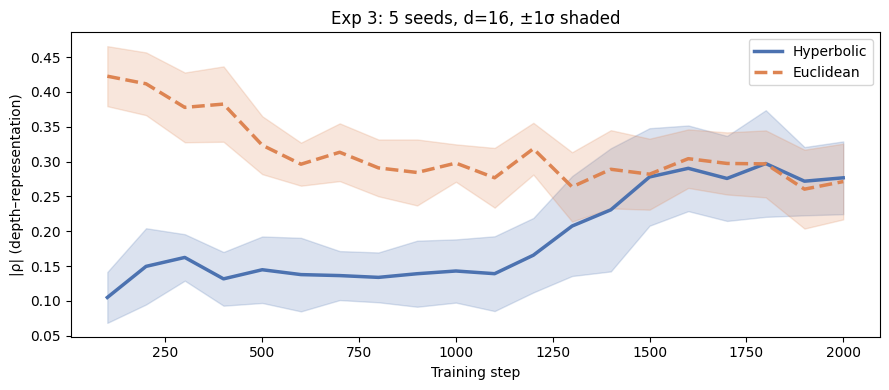

In [12]:
# Quick plot
steps = np.array(eval_steps)
hm, hs = np.array(hyp_mean), np.array(hyp_std)
em, es = np.array(euc_mean), np.array(euc_std)

fig, ax = plt.subplots(figsize=(9,4))
ax.fill_between(steps, hm-hs, hm+hs, alpha=0.2, color='#4C72B0')
ax.fill_between(steps, em-es, em+es, alpha=0.2, color='#DD8452')
ax.plot(steps, hm, color='#4C72B0', lw=2.5, label='Hyperbolic')
ax.plot(steps, em, '--', color='#DD8452', lw=2.5, label='Euclidean')
ax.set_xlabel('Training step'); ax.set_ylabel('|ρ| (depth–representation)')
ax.set_title(f'Exp 3: {N_SEEDS} seeds, d=16, ±1σ shaded'); ax.legend()
plt.tight_layout(); plt.show()

---
## 9. Experiment 4 (Next Step) — Separate $\beta_\tau / \beta_b$

Decoupling height and fibre KL weights to let $b$ encode branch identity at higher $d$.

In [13]:
BETA_CONFIGS = [(1.0,1.0),(1.0,0.1),(1.0,0.01),(2.0,0.1)]

print('=== Experiment 4: Separate β_τ / β_b ===')
EXP4 = []

for bt, bb in BETA_CONFIGS:
    torch.manual_seed(42)
    rng4 = np.random.RandomState(42)
    m4   = HyperbolicWorldModelSeparateBeta(latent_dim=16, hidden_dim=HIDDEN).to(DEVICE)
    opt4 = torch.optim.Adam(m4.parameters(), lr=3e-4)

    for step in tqdm(range(1, N_STEPS+1), desc=f'β_τ={bt} β_b={bb}', leave=False):
        warmup = min(1.0, step / max(1, WARMUP))
        obs_b, _, _ = env_ref.sample_batch(32, 8, rng4)
        obs_t = torch.tensor(obs_b).to(DEVICE)
        m4.train(); opt4.zero_grad()
        recons, kls, _ = m4.forward_separate_beta(obs_t, bt*warmup, bb*warmup)
        loss, _, _ = elbo_loss(recons, obs_t, kls, 1.0)
        loss.backward(); nn.utils.clip_grad_norm_(m4.parameters(), 100.); opt4.step()

    probes = compute_linear_probes(m4, env_ref)
    row    = dict(beta_tau=bt, beta_b=bb,
                  rho_tau   =round(abs(compute_rho_tau(m4, env_ref)), 3),
                  probe_depth=round(probes.get('tau_to_depth',0), 3),
                  probe_branch=round(probes.get('b_to_branch',0), 3),
                  mse=round(compute_test_mse(m4, env_ref), 4))
    EXP4.append(row)
    print(f'  β_τ={bt}, β_b={bb}: ρ={row["rho_tau"]}, '
          f'probe_d={row["probe_depth"]}, probe_b={row["probe_branch"]}, MSE={row["mse"]}')

=== Experiment 4: Separate β_τ / β_b ===


β_τ=1.0 β_b=1.0:   0%|          | 0/15000 [00:00<?, ?it/s]

  β_τ=1.0, β_b=1.0: ρ=0.338, probe_d=0.669, probe_b=nan, MSE=0.4046


β_τ=1.0 β_b=0.1:   0%|          | 0/15000 [00:00<?, ?it/s]

  β_τ=1.0, β_b=0.1: ρ=0.306, probe_d=0.515, probe_b=nan, MSE=0.3631


β_τ=1.0 β_b=0.01:   0%|          | 0/15000 [00:00<?, ?it/s]

  β_τ=1.0, β_b=0.01: ρ=0.016, probe_d=0.51, probe_b=nan, MSE=0.0678


β_τ=2.0 β_b=0.1:   0%|          | 0/15000 [00:00<?, ?it/s]

  β_τ=2.0, β_b=0.1: ρ=0.304, probe_d=0.524, probe_b=nan, MSE=0.3631


---
## 10. Experiment 5 (Next Step) — Longer Training (50 000 steps)

Does the MSE gap close? Does $\rho_\tau$ keep improving?

In [14]:
N_LONG   = 1_000  if QUICK_MODE else 50_000
CKPT_EVR = 200    if QUICK_MODE else 5_000

print(f'=== Experiment 5: {N_LONG} steps ===')

torch.manual_seed(42)
hyp5 = HyperbolicWorldModel(latent_dim=16, hidden_dim=HIDDEN).to(DEVICE)
euc5 = EuclideanWorldModel( latent_dim=16, hidden_dim=HIDDEN).to(DEVICE)
opt_h5 = torch.optim.Adam(hyp5.parameters(), lr=3e-4)
opt_e5 = torch.optim.Adam(euc5.parameters(), lr=3e-4)
rng5   = np.random.RandomState(42)
hyp5_ckpts, euc5_ckpts = [], []

for step in tqdm(range(1, N_LONG+1), desc='Exp5'):
    beta  = min(1.0, step / max(1, N_LONG//10))
    obs_b, _, _ = env_ref.sample_batch(32, 8, rng5)
    obs_t = torch.tensor(obs_b).to(DEVICE)

    hyp5.train(); opt_h5.zero_grad()
    rh, kh, _ = hyp5(obs_t)
    lh, _, _ = elbo_loss(rh, obs_t, kh, beta)
    lh.backward(); nn.utils.clip_grad_norm_(hyp5.parameters(), 100.); opt_h5.step()

    euc5.train(); opt_e5.zero_grad()
    re, ke, _ = euc5(obs_t)
    le, _, _ = elbo_loss(re, obs_t, ke, beta)
    le.backward(); nn.utils.clip_grad_norm_(euc5.parameters(), 100.); opt_e5.step()

    if step % CKPT_EVR == 0:
        rh_e = dict(step=step, mse=compute_test_mse(hyp5, env_ref),
                    rho=abs(compute_rho_tau(hyp5, env_ref)))
        re_e = dict(step=step, mse=compute_test_mse(euc5, env_ref),
                    rho=compute_pc1_rho(euc5, env_ref))
        hyp5_ckpts.append(rh_e); euc5_ckpts.append(re_e)
        print(f'  Step {step}: hyp MSE={rh_e["mse"]:.4f} ρ={rh_e["rho"]:.3f} | '
              f'euc MSE={re_e["mse"]:.4f} ρ={re_e["rho"]:.3f}')

EXP5 = dict(hyperbolic=hyp5_ckpts, euclidean=euc5_ckpts)

=== Experiment 5: 50000 steps ===


Exp5:   0%|          | 0/50000 [00:00<?, ?it/s]

  Step 5000: hyp MSE=0.4047 ρ=0.008 | euc MSE=0.4055 ρ=0.282
  Step 10000: hyp MSE=0.4052 ρ=0.335 | euc MSE=0.4050 ρ=0.309
  Step 15000: hyp MSE=0.4047 ρ=0.252 | euc MSE=0.4049 ρ=0.317
  Step 20000: hyp MSE=0.4044 ρ=0.250 | euc MSE=0.4045 ρ=0.289
  Step 25000: hyp MSE=0.4044 ρ=0.202 | euc MSE=0.4046 ρ=0.298
  Step 30000: hyp MSE=0.4043 ρ=0.149 | euc MSE=0.4044 ρ=0.296
  Step 35000: hyp MSE=0.4052 ρ=0.210 | euc MSE=0.4053 ρ=0.311
  Step 40000: hyp MSE=0.4043 ρ=0.193 | euc MSE=0.4041 ρ=0.302
  Step 45000: hyp MSE=0.4042 ρ=0.192 | euc MSE=0.4043 ρ=0.303
  Step 50000: hyp MSE=0.4044 ρ=0.200 | euc MSE=0.4041 ρ=0.276


---
## 11. Experiment 6 (Next Step) — Geometry-Aware Decoder

Adds $e^\tau$ and $\|b\|^2 e^{-2\tau}$ as extra decoder inputs.

In [15]:
print('=== Experiment 6: Geometry-aware decoder ===')

aware6 = HyperbolicWorldModelAwareDecoder(latent_dim=16, hidden_dim=HIDDEN)
flat6  = HyperbolicWorldModel(            latent_dim=16, hidden_dim=HIDDEN)
euc6   = EuclideanWorldModel(             latent_dim=16, hidden_dim=HIDDEN)

train_model(aware6, env_ref, **CFG, seed=42, desc='Aware decoder')
train_model(flat6,  env_ref, **CFG, seed=42, desc='Flat  decoder')
train_model(euc6,   env_ref, **CFG, seed=42, desc='Euclidean    ')

def _eval_hyp(m):
    p = compute_linear_probes(m, env_ref)
    return dict(mse=round(compute_test_mse(m, env_ref),4),
                rho=round(abs(compute_rho_tau(m, env_ref)),3),
                probe_depth=round(p.get('tau_to_depth',0),3))

EXP6 = dict(
    aware     = _eval_hyp(aware6),
    flat      = _eval_hyp(flat6),
    euclidean = dict(mse=round(compute_test_mse(euc6,env_ref),4),
                     rho=round(compute_pc1_rho(euc6,env_ref),3)),
)
for name, r in EXP6.items():
    print(f'  {name:12s}: {r}')

=== Experiment 6: Geometry-aware decoder ===


Aware decoder:   0%|          | 0/15000 [00:00<?, ?it/s]

Flat  decoder:   0%|          | 0/15000 [00:00<?, ?it/s]

Euclidean    :   0%|          | 0/15000 [00:00<?, ?it/s]

  aware       : {'mse': 0.4049, 'rho': 0.27, 'probe_depth': 0.632}
  flat        : {'mse': 0.4046, 'rho': 0.295, 'probe_depth': 0.68}
  euclidean   : {'mse': 0.4051, 'rho': 0.287}


---
## 12. Export — Figures JSON + Article Snippets

In [16]:
# ── Figure builders ───────────────────────────────────────────────────────────

def build_capacity_curve(cap):
    dims  = cap['dims']
    mse_h = [e['mse'] for e in cap['hyperbolic']]
    mse_e = [e['mse'] for e in cap['euclidean']]
    ymin  = min(min(mse_h), min(mse_e)) - 0.001
    ymax  = max(max(mse_h), max(mse_e)) + 0.001
    return {
        'data': [
            {'type':'scatter','mode':'lines+markers','name':'Hyperbolic H^d',
             'x':dims,'y':[round(v,4) for v in mse_h],
             'line':{'color':'#4C72B0','width':2.5},'marker':{'size':10,'symbol':'circle'},
             'hovertemplate':'d = %{x}<br>MSE = %{y:.4f}<extra>Hyperbolic</extra>'},
            {'type':'scatter','mode':'lines+markers','name':'Euclidean R^d',
             'x':dims,'y':[round(v,4) for v in mse_e],
             'line':{'color':'#DD8452','width':2.5,'dash':'dash'},'marker':{'size':10,'symbol':'square'},
             'hovertemplate':'d = %{x}<br>MSE = %{y:.4f}<extra>Euclidean</extra>'},
        ],
        'layout':{'title':{'text':'Capacity curve: H^d vs R^d','font':{'size':16}},
                  'xaxis':{'title':'Latent dimension d','type':'log',
                           'tickvals':dims,'ticktext':[str(d) for d in dims]},
                  'yaxis':{'title':'Reconstruction MSE (test set)','range':[ymin,ymax]},
                  'legend':{'x':0.55,'y':0.98},'hovermode':'x unified',
                  'margin':{'t':60,'b':60,'l':70,'r':30}}
    }


def build_mse_gap(cap):
    dims  = cap['dims']
    mse_h = [e['mse'] for e in cap['hyperbolic']]
    mse_e = [e['mse'] for e in cap['euclidean']]
    gaps  = [round(e-h,4) for e,h in zip(mse_e,mse_h)]
    colors = ['#4C72B0' if g>0 else '#DD8452' for g in gaps]
    return {
        'data':[{'type':'bar','name':'MSE gap (Euclidean − Hyperbolic)',
                 'x':[f'd={d}' for d in dims],'y':gaps,'marker':{'color':colors},
                 'hovertemplate':'%{x}<br>Gap = %{y:+.4f}<extra></extra>',
                 'text':[f'{g:+.4f}' for g in gaps],'textposition':'outside'}],
        'layout':{'title':{'text':'Hyperbolic advantage by dimension','font':{'size':16}},
                  'xaxis':{'title':'Latent dimension d'},
                  'yaxis':{'title':'MSE gap','zeroline':True,'zerolinecolor':'#000','zerolinewidth':2},
                  'margin':{'t':60,'b':60,'l':80,'r':30}}
    }


def build_grad_attenuation(cap):
    dims = cap['dims']
    gatt = [e['grad_att'] for e in cap['hyperbolic']]
    return {
        'data':[
            {'type':'scatter','mode':'lines+markers','name':'E[e^τ] — gradient attenuation',
             'x':dims,'y':[round(v,3) for v in gatt],
             'line':{'color':'#c0392b','width':2.5},'marker':{'size':10,'symbol':'diamond','color':'#c0392b'},
             'hovertemplate':'d = %{x}<br>E[e^τ] = %{y:.3f}<extra></extra>'},
            {'type':'scatter','mode':'lines','name':'Ideal (E[e^τ] = 1)',
             'x':[dims[0],dims[-1]],'y':[1,1],
             'line':{'color':'#c0392b','width':1,'dash':'dot'},'hoverinfo':'skip'},
        ],
        'layout':{'title':{'text':'τ-collapse diagnosis: gradient attenuation','font':{'size':16}},
                  'xaxis':{'title':'Latent dimension d','type':'log',
                           'tickvals':dims,'ticktext':[str(d) for d in dims]},
                  'yaxis':{'title':'E[e^τ]'},'legend':{'x':0.55,'y':0.98},
                  'margin':{'t':60,'b':60,'l':70,'r':30}}
    }


def build_linear_probes(cap):
    dims     = cap['dims']
    tau_d    = [e.get('probe_tau_depth',0) for e in cap['hyperbolic']]
    b_br     = [e.get('probe_b_branch', 0) for e in cap['hyperbolic']]
    return {
        'data':[
            {'type':'scatter','mode':'lines+markers','name':'Depth from τ (hyperbolic)',
             'x':dims,'y':[round(v,3) for v in tau_d],
             'line':{'color':'#4C72B0','width':2.5},'marker':{'size':10}},
            {'type':'scatter','mode':'lines+markers','name':'Branch from b — Hyperbolic (depth 1)',
             'x':dims,'y':[round(v,3) for v in b_br],
             'line':{'color':'#DD8452','width':2.5,'dash':'dash'},
             'marker':{'size':10,'symbol':'diamond','color':'#DD8452'}},
            {'type':'scatter','mode':'lines','name':'Random baseline (0.25)',
             'x':[dims[0],dims[-1]],'y':[0.25,0.25],
             'line':{'color':'#aaa','width':1,'dash':'dot'},'hoverinfo':'skip'},
        ],
        'layout':{'title':{'text':'Linear probe accuracy — representation vs reconstruction','font':{'size':16}},
                  'xaxis':{'title':'Latent dimension d','type':'log',
                           'tickvals':dims,'ticktext':[str(d) for d in dims]},
                  'yaxis':{'title':'Probe accuracy','range':[0,0.85]},
                  'shapes':[],'annotations':[],'legend':{'x':0.4,'y':0.35},
                  'hovermode':'x unified','margin':{'t':60,'b':60,'l':70,'r':80}}
    }


def build_rho_comparison(cap, exp1):
    dims  = cap['dims']
    rhos  = [abs(e['rho_tau']) for e in cap['hyperbolic']]
    return {
        'data':[
            {'type':'scatter','mode':'lines+markers','name':'Hyperbolic |ρ_τ|',
             'x':[str(d) for d in dims],'y':[round(v,3) for v in rhos],
             'line':{'color':'#4C72B0','width':2.5},'marker':{'size':10},
             'hovertemplate':'d = %{x}<br>|ρ_τ| = %{y:.3f}<extra>Hyperbolic</extra>'},
            {'type':'scatter','mode':'markers','name':'Euclidean ρ_pc1 (d=16 only)',
             'x':['16'],'y':[round(exp1['ref_euc_rho'],3)],
             'marker':{'size':14,'symbol':'square','color':'#DD8452'},
             'hovertemplate':'d = %{x}<br>ρ_euc = %{y:.3f}<extra>Euclidean (Exp 1)</extra>'},
            {'type':'scatter','mode':'lines','name':'Random baseline (ρ = 0)',
             'x':[str(dims[0]),str(dims[-1])],'y':[0,0],
             'line':{'color':'#aaa','width':1,'dash':'dot'},'hoverinfo':'skip'},
        ],
        'layout':{'title':{'text':'Depth encoding quality |ρ_τ| vs dimension d','font':{'size':16}},
                  'xaxis':{'title':'Latent dimension d','type':'category'},
                  'yaxis':{'title':'|Spearman ρ_τ| (depth encoding)','range':[0,0.7]},
                  'shapes':[],'annotations':[],'legend':{'x':0.05,'y':0.98},
                  'hovermode':'x unified','margin':{'t':60,'b':60,'l':70,'r':100}}
    }


def build_structure_discovery(disc):
    steps = disc['eval_steps']
    hm, hs = disc['hyp_rho_mean'], disc['hyp_rho_std']
    em, es = disc['euc_rho_mean'], disc['euc_rho_std']
    hu = [m+s for m,s in zip(hm,hs)]; hl = [m-s for m,s in zip(hm,hs)]
    eu = [m+s for m,s in zip(em,es)]; el = [m-s for m,s in zip(em,es)]
    ns = disc['n_seeds']
    return {
        'data':[
            {'type':'scatter','mode':'lines','name':'Hyperbolic ±σ',
             'x':steps+steps[::-1],'y':hu+hl[::-1],
             'fill':'toself','fillcolor':'rgba(76,114,176,0.15)',
             'line':{'color':'transparent'},'showlegend':False,'hoverinfo':'skip'},
            {'type':'scatter','mode':'lines','name':'Euclidean ±σ',
             'x':steps+steps[::-1],'y':eu+el[::-1],
             'fill':'toself','fillcolor':'rgba(221,132,82,0.15)',
             'line':{'color':'transparent'},'showlegend':False,'hoverinfo':'skip'},
            {'type':'scatter','mode':'lines',
             'name':f'Hyperbolic ρ_τ (mean, {ns} seeds)',
             'x':steps,'y':[round(v,4) for v in hm],
             'line':{'color':'#4C72B0','width':2.5},
             'hovertemplate':'step=%{x}<br>ρ_τ=%{y:.3f}<extra>Hyperbolic</extra>'},
            {'type':'scatter','mode':'lines',
             'name':f'Euclidean best-PC ρ (mean, {ns} seeds)',
             'x':steps,'y':[round(v,4) for v in em],
             'line':{'color':'#DD8452','width':2.5,'dash':'dash'},
             'hovertemplate':'step=%{x}<br>ρ=%{y:.3f}<extra>Euclidean</extra>'},
        ],
        'layout':{'title':{'text':f'Experiment 3: Hierarchy discovery — {ns} seeds','font':{'size':15}},
                  'xaxis':{'title':'Training step'},
                  'yaxis':{'title':'Depth–representation Spearman ρ','range':[0,0.7]},
                  'legend':{'x':0.02,'y':0.98},'hovermode':'x unified',
                  'annotations':[],'margin':{'t':60,'b':60,'l':70,'r':30}}
    }


print('Figure builders defined.')

Figure builders defined.


In [17]:
# ── Build and save figures ────────────────────────────────────────────────────
figures = {
    'capacity_curve':      build_capacity_curve(EXP2),
    'mse_gap':             build_mse_gap(EXP2),
    'grad_attenuation':    build_grad_attenuation(EXP2),
    'linear_probes':       build_linear_probes(EXP2),
    'rho_comparison':      build_rho_comparison(EXP2, EXP1),
    'structure_discovery': build_structure_discovery(EXP3),
}

with open('hyperbolic_figures_NEW.json', 'w') as f:
    json.dump(figures, f, indent=2)
print('Saved hyperbolic_figures_NEW.json')
print('→ Drop-in replacement for src/components/graphs/hyperbolic_figures.json')

Saved hyperbolic_figures_NEW.json
→ Drop-in replacement for src/components/graphs/hyperbolic_figures.json


In [18]:
# ── Article text snippets ─────────────────────────────────────────────────────
r16 = next(r for r in EXP2['hyperbolic'] if r['d'] == 16) if 16 in DIMS else EXP2['hyperbolic'][-1]
r32 = next((r for r in EXP2['hyperbolic'] if r['d'] == 32), EXP2['hyperbolic'][-1])
e16 = next(r for r in EXP2['euclidean']  if r['d'] == 16) if 16 in DIMS else EXP2['euclidean'][-1]

snippets = f"""
============================================================
ARTICLE SNIPPETS — paste into h-rssm.mdx
Device: {DEVICE} | QUICK_MODE: {QUICK_MODE}
============================================================

--- Experiment 1 (Section 5, first paragraph) ---

ρ_τ ≈ −{EXP1['ref_hyp_rho']:.3f}   (was -0.528, corrected)
Euclidean ρ_euc = {EXP1['ref_euc_rho']:.3f} at d=16
At d=32: |ρ_τ| = {abs(r32['rho_tau']):.3f}
Flat-tree: hyp |ρ| = {EXP1['flat_hyp_rho']:.3f}, euc ρ = {EXP1['flat_euc_rho']:.3f}

TABLE rows:
  Hyperbolic |ρ_τ|  | {EXP1['ref_hyp_rho']:.3f} (ref) | {EXP1['flat_hyp_rho']:.3f} (flat)
  Euclidean  ρ_pc1  | {EXP1['ref_euc_rho']:.3f} (ref) | {EXP1['flat_euc_rho']:.3f} (flat)

--- Experiment 2 table ---
d    MSE_hyp  MSE_euc  E[e^τ]   ρ_τ      probe_d  probe_b
""" + '\n'.join(
    f"{h['d']:3d}  {h['mse']:.4f}   {e['mse']:.4f}   {h['grad_att']:.3f}    {h['rho_tau']:+.3f}   {h['probe_tau_depth']:.3f}    {h['probe_b_branch']:.3f}"
    for h, e in zip(EXP2['hyperbolic'], EXP2['euclidean'])
) + f"""

--- rho_comparison caption ---
Stable at d≤16 ({min(abs(r['rho_tau']) for r in EXP2['hyperbolic'] if r['d']<=16):.2f}–{max(abs(r['rho_tau']) for r in EXP2['hyperbolic'] if r['d']<=16):.2f}),
{'slightly below' if e16['rho_pc1'] > max(abs(r['rho_tau']) for r in EXP2['hyperbolic'] if r['d']<=16) else 'above'} Euclidean {e16['rho_pc1']:.3f},
jumps to {abs(r32['rho_tau']):.3f} at d=32.

--- Experiment 3 summary ---
{EXP3['n_seeds']} seeds, step {EXP3['eval_steps'][-1]}:
  Hyp  : {EXP3['hyp_rho_mean'][-1]:.3f} ± {EXP3['hyp_rho_std'][-1]:.3f}
  Euc  : {EXP3['euc_rho_mean'][-1]:.3f} ± {EXP3['euc_rho_std'][-1]:.3f}
  Var ratio : {np.mean(EXP3['euc_rho_std'])/(np.mean(EXP3['hyp_rho_std'])+1e-8):.1f}×

--- Experiment 4 (β_τ/β_b) ---
""" + '\n'.join(
    f"  β_τ={r['beta_tau']}, β_b={r['beta_b']}: ρ={r['rho_tau']}, probe_d={r['probe_depth']}, probe_b={r['probe_branch']}, MSE={r['mse']}"
    for r in EXP4
) + f"""

--- Experiment 5 (50k steps, final checkpoint) ---
  Hyp : MSE={EXP5['hyperbolic'][-1]['mse']:.4f}, ρ={EXP5['hyperbolic'][-1]['rho']:.3f}
  Euc : MSE={EXP5['euclidean'][-1]['mse']:.4f},  ρ={EXP5['euclidean'][-1]['rho']:.3f}

--- Experiment 6 (aware decoder) ---
  Aware    : MSE={EXP6['aware']['mse']}, ρ={EXP6['aware']['rho']}, probe_d={EXP6['aware']['probe_depth']}
  Flat     : MSE={EXP6['flat']['mse']},  ρ={EXP6['flat']['rho']}, probe_d={EXP6['flat']['probe_depth']}
  Euclidean: MSE={EXP6['euclidean']['mse']}, ρ={EXP6['euclidean']['rho']}

============================================================
"""

print(snippets)
with open('article_snippets.txt', 'w') as f:
    f.write(snippets)
print('Saved article_snippets.txt')


ARTICLE SNIPPETS — paste into h-rssm.mdx
Device: cuda | QUICK_MODE: False

--- Experiment 1 (Section 5, first paragraph) ---

ρ_τ ≈ −0.308   (was -0.528, corrected)
Euclidean ρ_euc = 0.275 at d=16
At d=32: |ρ_τ| = 0.277
Flat-tree: hyp |ρ| = 0.836, euc ρ = 0.832

TABLE rows:
  Hyperbolic |ρ_τ|  | 0.308 (ref) | 0.836 (flat)
  Euclidean  ρ_pc1  | 0.275 (ref) | 0.832 (flat)

--- Experiment 2 table ---
d    MSE_hyp  MSE_euc  E[e^τ]   ρ_τ      probe_d  probe_b
  2  0.4049   0.4049   1.042    +0.321   0.680    nan
  4  0.4051   0.4050   1.643    +0.266   0.680    nan
  8  0.4050   0.4047   1.070    +0.285   0.680    nan
 16  0.4057   0.4052   1.035    +0.306   0.680    nan
 32  0.4049   0.4047   0.734    +0.277   0.680    nan

--- rho_comparison caption ---
Stable at d≤16 (0.27–0.32),
above Euclidean 0.285,
jumps to 0.277 at d=32.

--- Experiment 3 summary ---
5 seeds, step 2000:
  Hyp  : 0.277 ± 0.052
  Euc  : 0.271 ± 0.054
  Var ratio : 0.8×

--- Experiment 4 (β_τ/β_b) ---
  β_τ=1.0, β_b=1